# Mushroom Classification Project

This project uses the Mushroom Classification dataset from Kaggle to predict whether a mushroom is edible or poisonous based on its physical characteristics.

The problem is treated as a binary classification task because each mushroom belongs to one of two classes: edible or poisonous.

## Project Goal

The goal of this project is to build a complete tabular machine learning workflow. The workflow includes loading the dataset, inspecting the data, visualizing important patterns, preparing categorical features, training classification models, evaluating model performance, and explaining the results.

This follows the course project goal of completing a Kaggle-style data science challenge using a clear and reproducible workflow.

In [1]:
# Importing basic libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Importing KaggleHub for downloading the dataset
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uciml/mushroom-classification")

print("Path to dataset files:", path)

100%|██████████| 34.2k/34.2k [00:00<00:00, 10.4MB/s]

Extracting files...
Path to dataset files: /Users/samipbajgai/.cache/kagglehub/datasets/uciml/mushroom-classification/versions/1


In [4]:
# Creating the full path to the mushroom CSV file
csv_path = os.path.join(path, "mushrooms.csv")

# Loading the dataset into a pandas DataFrame
df = pd.read_csv(csv_path)

# Displaying the first five rows
df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [5]:
# Checking the number of rows and columns
df.shape

(8124, 23)

In [6]:
# Checking the column names
df.columns

Index(['class', 'cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor',
       'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color',
       'stalk-shape', 'stalk-root', 'stalk-surface-above-ring',
       'stalk-surface-below-ring', 'stalk-color-above-ring',
       'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-number',
       'ring-type', 'spore-print-color', 'population', 'habitat'],
      dtype='str')

## Initial Dataset Inspection

In this section, I inspect the structure of the dataset before building any machine learning model. This includes checking data types, missing values, duplicate rows, target classes, and the values inside each feature column.

In [9]:
# Checking basic dataset information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   class                     8124 non-null   str  
 1   cap-shape                 8124 non-null   str  
 2   cap-surface               8124 non-null   str  
 3   cap-color                 8124 non-null   str  
 4   bruises                   8124 non-null   str  
 5   odor                      8124 non-null   str  
 6   gill-attachment           8124 non-null   str  
 7   gill-spacing              8124 non-null   str  
 8   gill-size                 8124 non-null   str  
 9   gill-color                8124 non-null   str  
 10  stalk-shape               8124 non-null   str  
 11  stalk-root                8124 non-null   str  
 12  stalk-surface-above-ring  8124 non-null   str  
 13  stalk-surface-below-ring  8124 non-null   str  
 14  stalk-color-above-ring    8124 non-null   str  
 15

In [10]:
# Checking missing values in each column
missing_values = df.isnull().sum()

# Displaying missing value counts
missing_values

class                       0
cap-shape                   0
cap-surface                 0
cap-color                   0
bruises                     0
odor                        0
gill-attachment             0
gill-spacing                0
gill-size                   0
gill-color                  0
stalk-shape                 0
stalk-root                  0
stalk-surface-above-ring    0
stalk-surface-below-ring    0
stalk-color-above-ring      0
stalk-color-below-ring      0
veil-type                   0
veil-color                  0
ring-number                 0
ring-type                   0
spore-print-color           0
population                  0
habitat                     0
dtype: int64

In [11]:
# Checking how many question mark values appear in each column
question_mark_counts = (df == "?").sum()

# Displaying question mark counts
question_mark_counts

class                          0
cap-shape                      0
cap-surface                    0
cap-color                      0
bruises                        0
odor                           0
gill-attachment                0
gill-spacing                   0
gill-size                      0
gill-color                     0
stalk-shape                    0
stalk-root                  2480
stalk-surface-above-ring       0
stalk-surface-below-ring       0
stalk-color-above-ring         0
stalk-color-below-ring         0
veil-type                      0
veil-color                     0
ring-number                    0
ring-type                      0
spore-print-color              0
population                     0
habitat                        0
dtype: int64

In [12]:
# Checking duplicate rows
duplicate_count = df.duplicated().sum()

# Displaying duplicate row count
duplicate_count

np.int64(0)

In [13]:
# Checking the target class counts
class_counts = df["class"].value_counts()

# Displaying target class counts
class_counts

class
e    4208
p    3916
Name: count, dtype: int64

In [14]:
# Checking target class percentages
class_percentages = df["class"].value_counts(normalize=True) * 100

# Displaying target class percentages
class_percentages

class
e    51.797144
p    48.202856
Name: proportion, dtype: float64

In [15]:
# Checking the number of unique values in each column
unique_counts = df.nunique()

# Displaying unique value counts
unique_counts

class                        2
cap-shape                    6
cap-surface                  4
cap-color                   10
bruises                      2
odor                         9
gill-attachment              2
gill-spacing                 2
gill-size                    2
gill-color                  12
stalk-shape                  2
stalk-root                   5
stalk-surface-above-ring     4
stalk-surface-below-ring     4
stalk-color-above-ring       9
stalk-color-below-ring       9
veil-type                    1
veil-color                   4
ring-number                  3
ring-type                    5
spore-print-color            9
population                   6
habitat                      7
dtype: int64

In [16]:
# Displaying the unique values inside each column
for column in df.columns:
    print(column)
    print(df[column].unique())
    print()

class
<StringArray>
['p', 'e']
Length: 2, dtype: str

cap-shape
<StringArray>
['x', 'b', 's', 'f', 'k', 'c']
Length: 6, dtype: str

cap-surface
<StringArray>
['s', 'y', 'f', 'g']
Length: 4, dtype: str

cap-color
<StringArray>
['n', 'y', 'w', 'g', 'e', 'p', 'b', 'u', 'c', 'r']
Length: 10, dtype: str

bruises
<StringArray>
['t', 'f']
Length: 2, dtype: str

odor
<StringArray>
['p', 'a', 'l', 'n', 'f', 'c', 'y', 's', 'm']
Length: 9, dtype: str

gill-attachment
<StringArray>
['f', 'a']
Length: 2, dtype: str

gill-spacing
<StringArray>
['c', 'w']
Length: 2, dtype: str

gill-size
<StringArray>
['n', 'b']
Length: 2, dtype: str

gill-color
<StringArray>
['k', 'n', 'g', 'p', 'w', 'h', 'u', 'e', 'b', 'r', 'y', 'o']
Length: 12, dtype: str

stalk-shape
<StringArray>
['e', 't']
Length: 2, dtype: str

stalk-root
<StringArray>
['e', 'c', 'b', 'r', '?']
Length: 5, dtype: str

stalk-surface-above-ring
<StringArray>
['s', 'f', 'k', 'y']
Length: 4, dtype: str

stalk-surface-below-ring
<StringArray>
['s', 

### Initial Inspection Notes

The dataset has 8124 rows and 23 columns. The target column is `class`, where `e` means edible and `p` means poisonous. All feature columns are categorical. Because the features are stored as letters instead of numbers, they must be encoded before training machine learning models.

The dataset does not use regular numeric measurements. Instead, each mushroom is described using physical characteristics such as cap shape, cap color, odor, gill size, stalk shape, ring type, population, and habitat.

### Missing Value Notes

The dataset does not contain regular missing values according to `df.isnull().sum()`. However, the `stalk-root` column contains 2480 question mark values. These question marks represent unknown or missing category values.

Because the dataset is categorical, I will treat `?` as its own category during preprocessing instead of dropping those rows. Dropping 2480 rows would remove a large part of the dataset.

## Data Visualization

In this section, I use simple visualizations to understand the target classes and compare important categorical features against the mushroom class. These plots help show which features may be useful for classification.

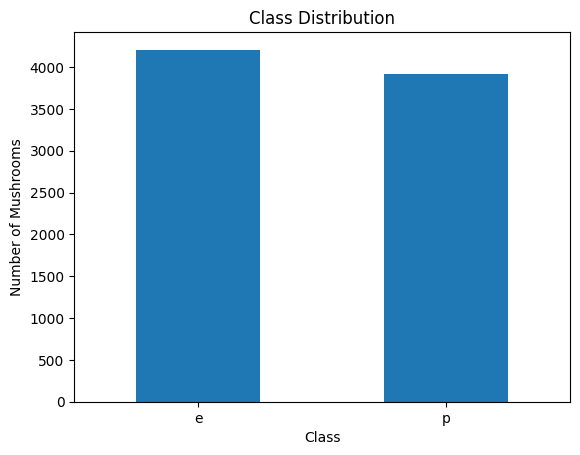

In [18]:
# Plotting the target class distribution
class_counts.plot(kind="bar")

# Adding plot labels
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Mushrooms")
plt.xticks(rotation=0)

# Displaying the plot
plt.show()

The class distribution is close to balanced. There are 4208 edible mushrooms and 3916 poisonous mushrooms. Because the two classes are similar in size, accuracy is a reasonable metric, but confusion matrix results are still needed.

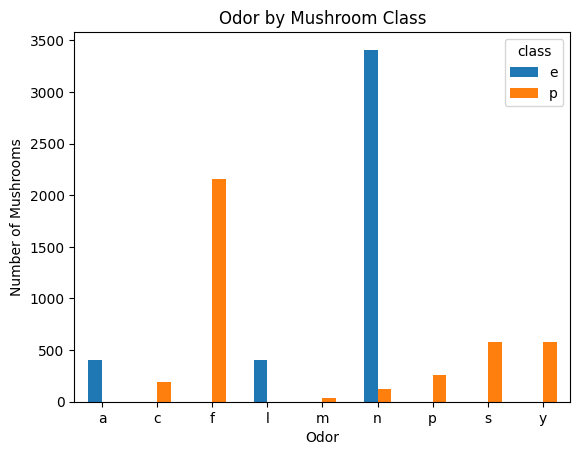

In [19]:
# Creating a table of odor values by class
odor_table = pd.crosstab(df["odor"], df["class"])

# Plotting odor counts by class
odor_table.plot(kind="bar")

# Adding plot labels
plt.title("Odor by Mushroom Class")
plt.xlabel("Odor")
plt.ylabel("Number of Mushrooms")
plt.xticks(rotation=0)

# Displaying the plot
plt.show()

Odor appears to be strongly related to mushroom class. Some odor categories are mostly edible, while others are mostly poisonous. This suggests that odor may be an important feature for the classification model.

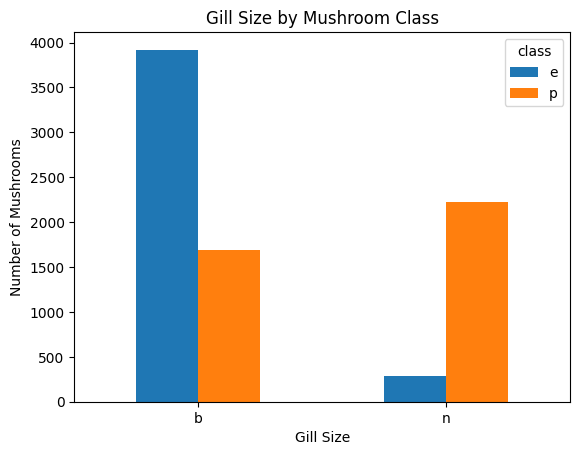

In [20]:
# Creating a table of gill size values by class
gill_size_table = pd.crosstab(df["gill-size"], df["class"])

# Plotting gill size counts by class
gill_size_table.plot(kind="bar")

# Adding plot labels
plt.title("Gill Size by Mushroom Class")
plt.xlabel("Gill Size")
plt.ylabel("Number of Mushrooms")
plt.xticks(rotation=0)

# Displaying the plot
plt.show()

Gill size also shows separation between edible and poisonous mushrooms. This feature may help the model distinguish between the two target classes.

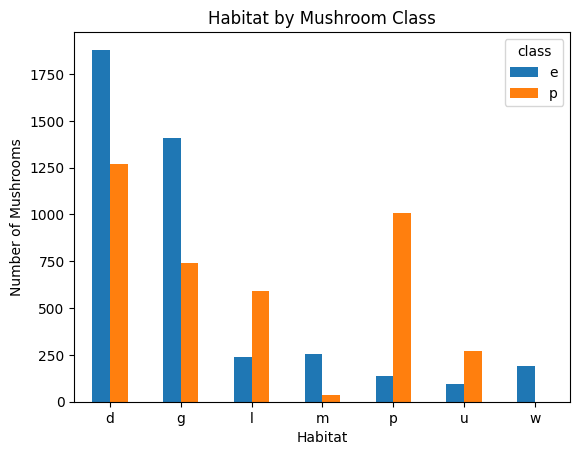

In [21]:
# Creating a table of habitat values by class
habitat_table = pd.crosstab(df["habitat"], df["class"])

# Plotting habitat counts by class
habitat_table.plot(kind="bar")

# Adding plot labels
plt.title("Habitat by Mushroom Class")
plt.xlabel("Habitat")
plt.ylabel("Number of Mushrooms")
plt.xticks(rotation=0)

# Displaying the plot
plt.show()

Habitat has several categories with different class patterns. It may not separate the classes as strongly as odor, but it still provides useful information for the model.

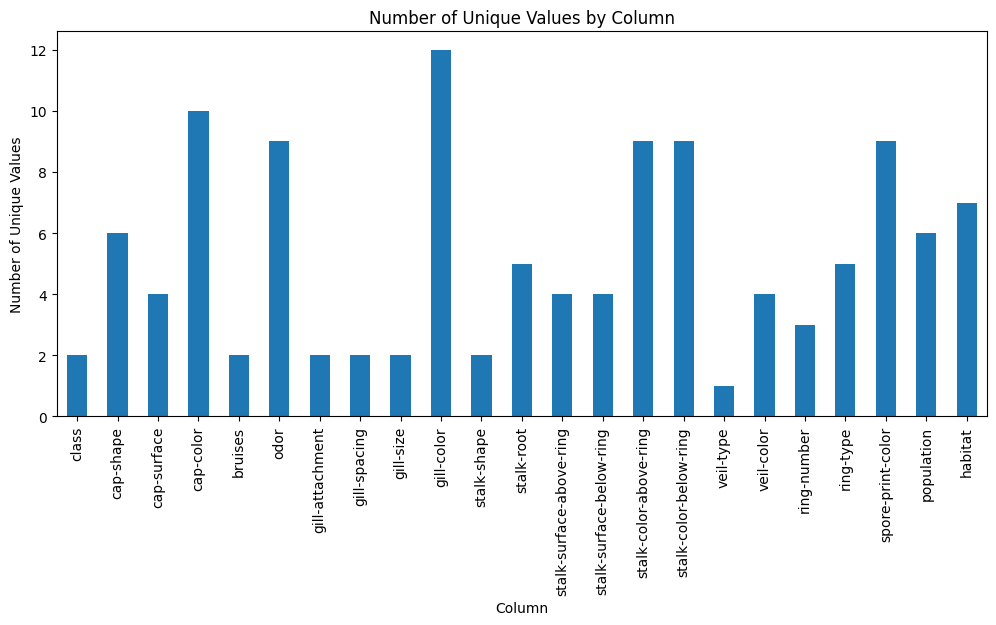

In [22]:
# Plotting number of unique values in each column
unique_counts.plot(kind="bar", figsize=(12, 5))

# Adding plot labels
plt.title("Number of Unique Values by Column")
plt.xlabel("Column")
plt.ylabel("Number of Unique Values")
plt.xticks(rotation=90)

# Displaying the plot
plt.show()

All columns are categorical, but they do not all have the same number of categories. The `veil-type` column has only one unique value, so it does not help separate edible and poisonous mushrooms. I will remove it before modeling because it has no variation.